## Classificando diferentes tipos de semente de abóbora 🎃🌱

As sementes de abóbora são frequentemente consumidas como confeitos em todo o mundo devido à sua quantidade adequada de proteínas, gorduras, carboidratos e teores minerais. A base de dados **"SementesAbobora.xlsx"** possui um estudo foi realizado nos dois tipos de sementes de abóbora mais importantes e de qualidade, **“Ürgüp Sivrisi”** e **“Çerçevelik”**, geralmente cultivadas nas regiões de Ürgüp e Karacaören na Turquia.

Muitas espécies de sementes têm semelhanças visuais, o que torna a classificação manual difícil e sujeita a erros. Redes neurais podem ser treinadas para identificar padrões que não são facilmente perceptíveis pelo olho humano, aumentando a precisão da classificação.

Imagine que foi proposto para você o desafio de criar uma **inteligência para identificar os tipos de sementes para ajudar a equipe de engenheiros e engenheiras Agrícolas**. Para trabalhar com a precisão dos resultados x complexidade das características de sementes, você optou em utilizar as **redes neurais multilayer perceptron**. Vamos para a aplicação?

### Features

- Perímetro
- Maior_Eixo_Comprimento
- Comprimento_Eixo_Menor
- Área_Convexa
- Equiv_Diâmetro
- Excentricidade
- Solidez
- Extensão
- Redondeza
- Proporcao
- Compacidade

### Target
Classes:
 ((A)Çerçevelik, (B)Ürgüp Sivrisi)
 

In [44]:
import pandas as pd
from sklearn.utils import shuffle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras import metrics
from keras.optimizers import Adam
from keras.metrics import Precision
from tqdm.keras import TqdmCallback

ImportError: Traceback (most recent call last):
  File "c:\Users\gabri\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: Uma rotina de inicialização da biblioteca de vínculo dinâmico (DLL) falhou.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [2]:
df = pd.read_excel("SementesAbobora.xlsx")

In [3]:
df.head()

,Area,Perímetro,Maior_Eixo_Comprimento,Comprimento_Eixo_Menor,Área_Convexa,Equiv_Diâmetro,Excentricidade,Solidez,Extensão,Redondeza,Proporcao,Compacidade,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,(A) Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,(A) Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,(A) Çerçevelik
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,(A) Çerçevelik
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,(A) Çerçevelik


In [6]:
df.tail()

,Area,Perímetro,Maior_Eixo_Comprimento,Comprimento_Eixo_Menor,Área_Convexa,Equiv_Diâmetro,Excentricidade,Solidez,Extensão,Redondeza,Proporcao,Compacidade,Class
2495,79637,1224.710,533.1513,190.4367,80381,318.4289,0.9340,0.9907,0.4888,0.6672,2.7996,0.5973,(B) Ürgüp Sivrisi
2496,69647,1084.318,462.9416,191.8210,70216,297.7874,0.9101,0.9919,0.6002,0.7444,2.4134,0.6433,(B) Ürgüp Sivrisi
2497,87994,1210.314,507.2200,222.1872,88702,334.7199,0.8990,0.9920,0.7643,0.7549,2.2828,0.6599,(B) Ürgüp Sivrisi
2498,80011,1182.947,501.9065,204.7531,80902,319.1758,0.9130,0.9890,0.7374,0.7185,2.4513,0.6359,(B) Ürgüp Sivrisi
2499,84934,1159.933,462.8951,234.5597,85781,328.8485,0.8621,0.9901,0.7360,0.7933,1.9735,0.7104,(B) Ürgüp Sivrisi


In [4]:
df.shape

(2500, 13)

Observe que essa base de dados possui os dados de classes de forma ordenada, isso poder ser um problema para o aprendizado de máquina.
Vamos começar a já embaralhar os dados com o comando shuffle.

In [7]:
df = shuffle(df)

In [8]:
df.head()

,Area,Perímetro,Maior_Eixo_Comprimento,Comprimento_Eixo_Menor,Área_Convexa,Equiv_Diâmetro,Excentricidade,Solidez,Extensão,Redondeza,Proporcao,Compacidade,Class
2174,69872,1074.934,446.3577,199.7382,70550,298.2680,0.8943,0.9904,0.6870,0.7599,2.2347,0.6682,(B) Ürgüp Sivrisi
1673,81944,1223.373,524.5474,199.5556,83000,323.0083,0.9248,0.9873,0.6714,0.6880,2.6286,0.6158,(B) Ürgüp Sivrisi
659,96327,1179.480,453.4745,271.2626,97246,350.2104,0.8014,0.9905,0.7393,0.8701,1.6717,0.7723,(A) Çerçevelik
2261,81665,1158.432,476.5435,218.6615,82439,322.4579,0.8885,0.9906,0.6625,0.7647,2.1794,0.6767,(B) Ürgüp Sivrisi
2195,99695,1279.760,535.8074,237.3569,100429,356.2802,0.8965,0.9927,0.5877,0.7649,2.2574,0.6649,(B) Ürgüp Sivrisi


Com os dados embaralhados o próximo passo é conhecer o equilibrio das classes (já que temos o problema de classificação a ser resolvido)

In [9]:
df['Class'].value_counts

<bound method IndexOpsMixin.value_counts of 2174    (B) Ürgüp Sivrisi
1673    (B) Ürgüp Sivrisi
659       (A) Çerçevelik 
2261    (B) Ürgüp Sivrisi
2195    (B) Ürgüp Sivrisi
              ...        
1062      (A) Çerçevelik 
276       (A) Çerçevelik 
1426    (B) Ürgüp Sivrisi
2404    (B) Ürgüp Sivrisi
2306    (B) Ürgüp Sivrisi
Name: Class, Length: 2500, dtype: object>

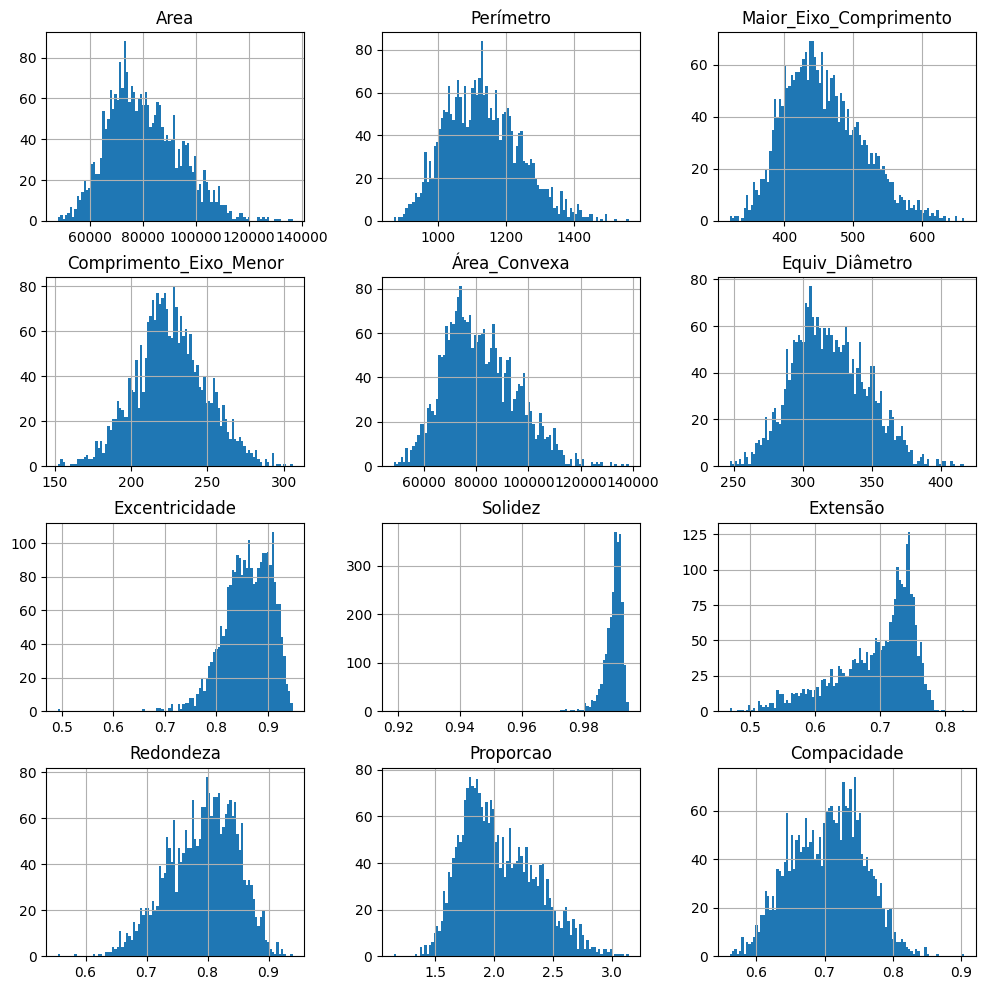

In [11]:
df.hist(bins=100, figsize=(12,12))
plt.show()

<AxesSubplot: >

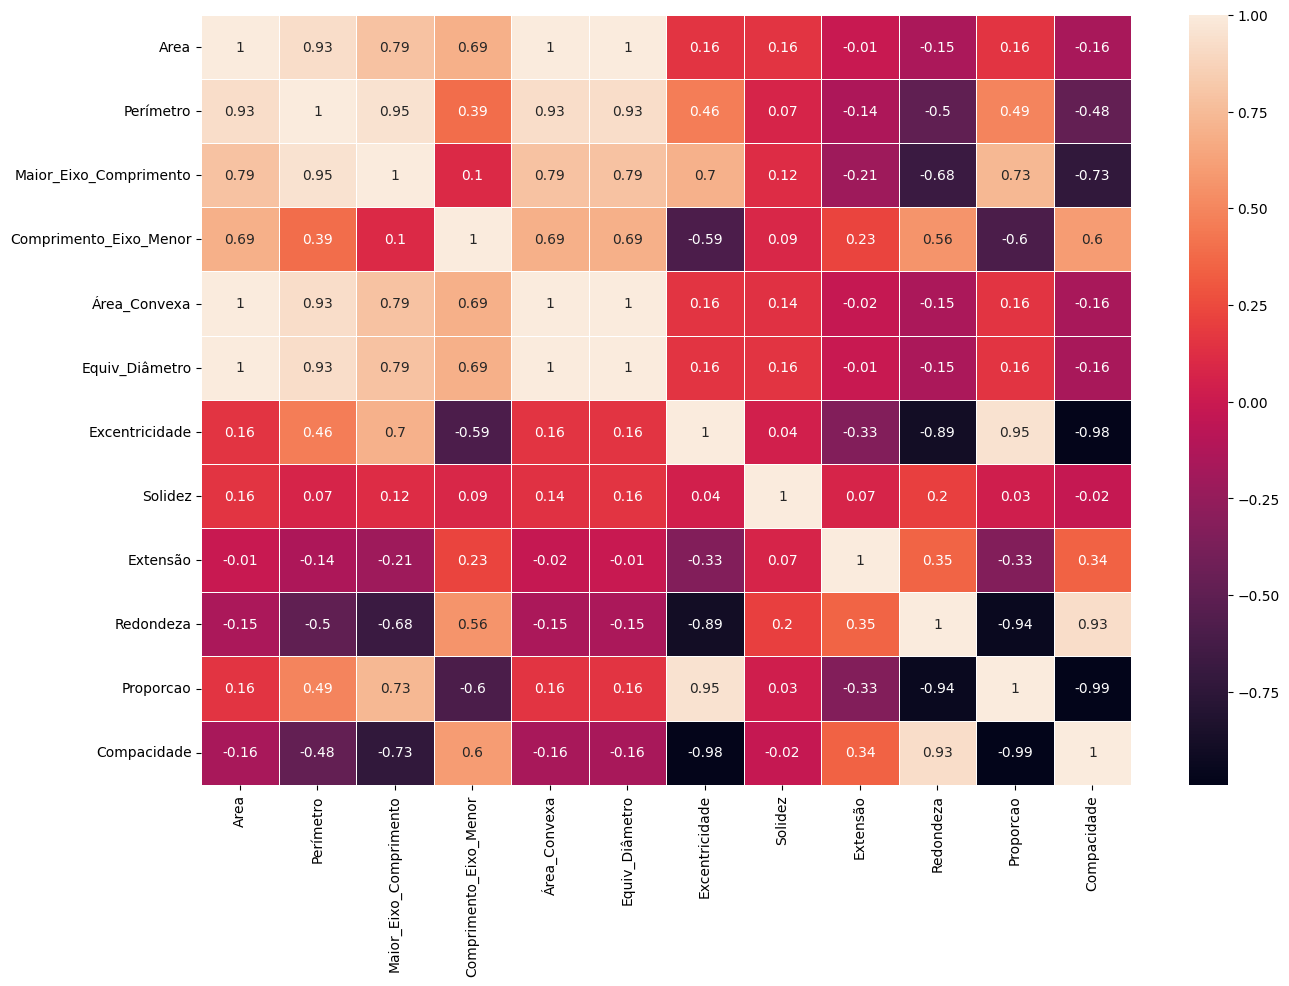

In [15]:
correlation_matrix = df.select_dtypes(include='number').corr().round(2)

fig, ax = plt.subplots(figsize=(15,10))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 2174 to 2306
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area                    2500 non-null   int64  
 1   Perímetro               2500 non-null   float64
 2   Maior_Eixo_Comprimento  2500 non-null   float64
 3   Comprimento_Eixo_Menor  2500 non-null   float64
 4   Área_Convexa            2500 non-null   int64  
 5   Equiv_Diâmetro          2500 non-null   float64
 6   Excentricidade          2500 non-null   float64
 7   Solidez                 2500 non-null   float64
 8   Extensão                2500 non-null   float64
 9   Redondeza               2500 non-null   float64
 10  Proporcao               2500 non-null   float64
 11  Compacidade             2500 non-null   float64
 12  Class                   2500 non-null   object 
dtypes: float64(10), int64(2), object(1)
memory usage: 273.4+ KB


In [18]:
le = LabelEncoder()
df.Class = le.fit_transform(df['Class'])

In [19]:
set(df['Class'])

{0, 1}

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 2174 to 2306
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area                    2500 non-null   int64  
 1   Perímetro               2500 non-null   float64
 2   Maior_Eixo_Comprimento  2500 non-null   float64
 3   Comprimento_Eixo_Menor  2500 non-null   float64
 4   Área_Convexa            2500 non-null   int64  
 5   Equiv_Diâmetro          2500 non-null   float64
 6   Excentricidade          2500 non-null   float64
 7   Solidez                 2500 non-null   float64
 8   Extensão                2500 non-null   float64
 9   Redondeza               2500 non-null   float64
 10  Proporcao               2500 non-null   float64
 11  Compacidade             2500 non-null   float64
 12  Class                   2500 non-null   int32  
dtypes: float64(10), int32(1), int64(2)
memory usage: 263.7 KB


In [27]:
x = df[['Area','Perímetro','Comprimento_Eixo_Menor','Excentricidade','Solidez','Extensão','Redondeza','Proporcao','Compacidade']]
y = df['Class']

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20)

In [30]:
scaler = StandardScaler()
scaler.fit(x_train)
scaler.fit(x_test)

StandardScaler()

In [31]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [32]:
x_train

array([[ 2.04050819e-01,  6.37385997e-02,  5.44150652e-01, ...,
         3.70028522e-01, -5.07748837e-01,  4.36276827e-01],
       [ 1.07658237e+00,  1.09680479e+00,  4.52205505e-01, ...,
        -4.63592463e-01,  4.85933792e-01, -5.76277529e-01],
       [-1.25112186e-01, -3.43102585e-01,  1.66358338e-01, ...,
         7.47733225e-01, -4.11533037e-01,  3.44933152e-01],
       ...,
       [-5.01623571e-01,  8.00704963e-02, -1.00634912e+00, ...,
        -1.45172901e+00,  9.20054227e-01, -1.04465680e+00],
       [ 1.08399749e-01,  3.87086189e-01, -5.90389315e-01, ...,
        -7.70715984e-01,  9.24979951e-01, -9.49426159e-01],
       [ 4.20458610e-01, -1.17423756e-03,  1.16009293e+00, ...,
         1.11589993e+00, -9.77662863e-01,  1.01349111e+00]])

In [33]:
x_test

array([[-1.03500858, -1.31475827,  0.05861288, ...,  1.27804589,
        -1.25153309,  1.35943099],
       [-0.35032898, -0.61348211,  0.17576423, ...,  0.98809076,
        -0.66865581,  0.64617293],
       [ 1.17568363,  1.50036485, -0.00847541, ..., -1.24761586,
         1.2858713 , -1.2662138 ],
       ...,
       [-1.0078475 , -1.41933033,  0.41725291, ...,  1.75494576,
        -1.60158785,  1.8900017 ],
       [ 2.05430807,  2.17837819,  0.76773408, ..., -1.16749668,
         1.00182124, -1.01744805],
       [ 0.94173125,  0.62811991,  1.1960184 , ...,  0.50165289,
        -0.54058699,  0.46737255]])

In [34]:
x_test.shape

(500, 9)

In [35]:
type(y_train)

pandas.core.series.Series

In [40]:
y_train = np.asarray(y_train).astype('float32').reshape((-1,1))
y_test = np.asarray(y_test).astype('float32').reshape((-1,1))

In [41]:
type(y_train)

numpy.ndarray

In [42]:
y_train.shape

(2000, 1)